# Exercise 3: YOLO Object Detection

Welcome to the third exercise of **Generative AI** from the research group **Visual Computing and Artificial Intelligence (VCAI)**!

In this notebook, a model is trained that can detect fire and smoke in images. For this we use the DFire dataset and a YOLOv8n model.   
You should use this page as a guide for implementation: https://docs.ultralytics.com/modes/

**What we expect:**
- Data:
  - Use code to load the dataset from the download link 
  - Analyze the dataset
  - Perform preprocessing steps if necessary
- Model:
  - Load the model
  - Train the model on the custom dataset
  - Discuss training metrics
- Test:
  - Test the model on unseen data
  - Discuss the test results


**Note:**  
Please only insert your code in the spaces provided. If absolutely necessary, additional cells can also be created. The basic structure and clarity should be maintained.

## Exercise Group Information
- Group Number: FILL IN YOUR GROUP NUMBER
- Group Members: FILL IN THE NAMES OF ALL GROUP MEMBERS

## Table of Contents

- [1. Packages](#1)
  - [1.1 Import Packages](#1-1)
  - [1.2 GPU Usage](#1-2)
- [2. Data](#2)
  - [2.1 Download Dataset](#2-1) 
  - [2.2 Analyze the Dataset](#2-2)
  - [2.3 Preprocessing (if necessary)](#2-3)
- [3. YOLOv8n](#3)
  - [3.1 Load the Model](#3-1) 
  - [3.2 Train the Model](#3-2)
  - [3.3 Discuss the Training Results](#3-3)
- [4. Test](#4)
  - [4.1 Test the Model](#4-1) 
  - [4.2 Discuss the Test Results](#4-2)


<a name="1"></a>
## 1. Packages

<a name="1-1"></a>
### 1.1 Import Packages
Please import all required packages, dependencies, and custom utility functions.

In [1]:
### START YOUR CODE HERE ###

# Basic packages
import os
import random
import glob
import yaml
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Do not import TensorFlow because it crashes this kernel.
# Create a dummy tf variable so later checks do not fail.
tf = None
print("TensorFlow skipped because it crashes this environment.")

# PyTorch/Ultralytics for YOLOv8
import torch

try:
    from ultralytics import YOLO
except ImportError:
    !pip install ultralytics -q
    from ultralytics import YOLO

# Image reading/drawing
import cv2

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

### END OF YOUR CODE ###

TensorFlow skipped because it crashes this environment.
PyTorch: 2.12.0+cu130
CUDA available: False
Running on CPU


<a name="1-2"></a>
### 1.2 GPU Usage
In order to speed up the training process, it is recommended to use the GPU (see Exercise Information Sheet in OpenOlat).

In [4]:
if tf is not None:
    physical_devices = tf.config.list_physical_devices('GPU')
    try:
        print(physical_devices[0])
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    except:
        pass
else:
    print("Skipping TensorFlow GPU check.")

Skipping TensorFlow GPU check.


In [3]:
physical_devices = tf.config.list_physical_devices('GPU')
try:
  print(physical_devices[0])
  tf.config.experimental.set_memory_growth(physical_devices[0], True)
except:
  # Invalid device or cannot modify virtual devices once initialized.
  pass

Skipping TensorFlow GPU check.


<a name="2"></a>
## 2. Data

<a name="2-1"></a>
### 2.1 Download Dataset
Download the dataset.

In [5]:
! wget -O D-Fire.zip "https://cloud.rz.uni-kiel.de/public.php/dav/files/s5pQKX5ZieTAqk6" 
! unzip D-Fire.zip -d D-Fire



7[Files: 0  Bytes: 0  [0 B/s] Re]87[https://cloud.rz.uni-kiel.de/p]87[Files: 0  Bytes: 0  [0 B/s] Re]87Saving 'D-Fire.zip'
87D-Fire.zip             0% [>                             ]  206.88K    --.-KB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87[Files: 0  Bytes: 0  [0 B/s] Re]87D-Fire.zip             0% [>                             ]    1.88M    1.68MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87D-Fire.zip             0% [>                             ]   24.81M   12.29MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87D-Fire.zip             1% [>                             ]   57.57M   19.11MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87D-Fire.zip             2% [>                             ]   75.08M   18.71MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87D-Fire.zip             3% [>                             ]   93.89M   18.73MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87D-Fire.zip             3% [>                             ]  113.90M   18.94MB/s87[Files: 0  Bytes: 0  [0 B/s] Re

<a name="2-2"></a>
### 2.2 Analyze the Dataset
Analyze the data set to the appropriate extent. For example, images and labels can be shown.

Number of images: 21527
Number of label files: 21527

Main folders:
 - D-Fire/test
 - D-Fire/train

Images with at least one object: 11689
Class/object counts: {0: 11865, 1: 14692}
Class 0 = smoke, Class 1 = fire
Image: D-Fire/train/images/WEB08437.jpg


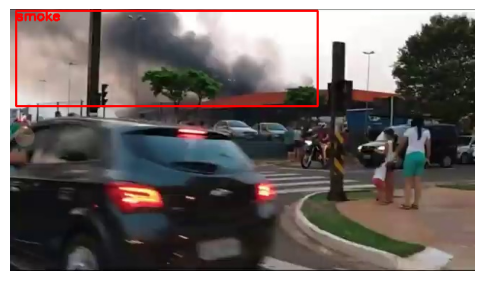

Image: D-Fire/train/images/PublicDataset00067.jpg


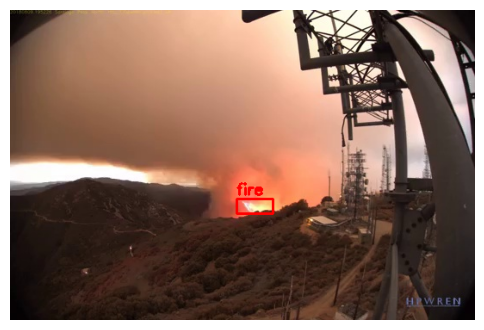

Image: D-Fire/train/images/AoF06441.jpg


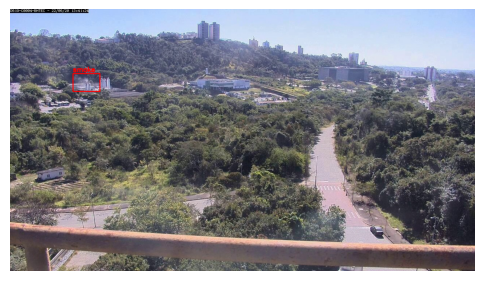

In [6]:
### START YOUR CODE HERE ###

# Find image and label files after unzipping
dataset_root = Path("D-Fire")

image_extensions = ["*.jpg", "*.jpeg", "*.png"]
image_files = []
for ext in image_extensions:
    image_files.extend(list(dataset_root.rglob(ext)))

label_files = list(dataset_root.rglob("*.txt"))

print("Number of images:", len(image_files))
print("Number of label files:", len(label_files))

# Show possible folder structure
print("\nMain folders:")
for p in sorted(dataset_root.glob("*")):
    if p.is_dir():
        print(" -", p)

# Count objects/classes from YOLO label files
class_count = {0: 0, 1: 0}
images_with_objects = 0

for label_path in label_files:
    lines = label_path.read_text().strip().splitlines()
    if len(lines) > 0:
        images_with_objects += 1

    for line in lines:
        parts = line.split()
        if len(parts) >= 5:
            cls = int(float(parts[0]))
            class_count[cls] = class_count.get(cls, 0) + 1

print("\nImages with at least one object:", images_with_objects)
print("Class/object counts:", class_count)
print("Class 0 = smoke, Class 1 = fire")

# Helper function to draw YOLO boxes
def show_yolo_image(image_path, label_path=None, class_names=("smoke", "fire")):
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if label_path is not None and Path(label_path).exists():
        for line in Path(label_path).read_text().strip().splitlines():
            parts = line.split()
            if len(parts) < 5:
                continue

            cls, x_center, y_center, box_w, box_h = map(float, parts[:5])

            x1 = int((x_center - box_w / 2) * w)
            y1 = int((y_center - box_h / 2) * h)
            x2 = int((x_center + box_w / 2) * w)
            y2 = int((y_center + box_h / 2) * h)

            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(
                img,
                class_names[int(cls)],
                (x1, max(y1 - 5, 15)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 0, 0),
                2
            )

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# Show a few random labeled samples
sample_images = random.sample(image_files, min(3, len(image_files)))

for img_path in sample_images:
    # YOLO labels usually have the same filename but .txt extension
    possible_label = Path(str(img_path).replace("/images/", "/labels/")).with_suffix(".txt")
    if not possible_label.exists():
        possible_label = img_path.with_suffix(".txt")

    print("Image:", img_path)
    show_yolo_image(img_path, possible_label)

### END OF YOUR CODE ###


<a name="2-3"></a>
### 2.3 Preprocessing (if necessary)
Justify whether pre-processing steps are necessary and implement them (if none are necessary, this should be clear from the discussion). These steps can also concern the folder structure or similar. 

The dataset is already in YOLO format because every image has a corresponding `.txt` label file.  
Each label row contains: class id, x-center, y-center, width, and height.  
The coordinates are normalized between 0 and 1, which is exactly what YOLO needs.

Therefore, no image preprocessing is necessary.  
The only required preprocessing step is creating `config.yaml`, so YOLO knows the train/validation image folders, number of classes, and class names.


In [7]:
### START YOUR CODE HERE ###

# Create a YOLO config file.
# YOLOv8 expects this format:
# train: path/to/train/images
# val: path/to/val/images
# nc: number of classes
# names: class names

def find_image_folder(root, split_name):
    candidates = [
        root / split_name / "images",
        root / "images" / split_name,
        root / split_name,
    ]

    for c in candidates:
        if c.exists() and any(c.rglob("*.jpg")):
            return c

    # fallback: search folders that contain the split name and images
    for c in root.rglob("*"):
        if c.is_dir() and split_name.lower() in str(c).lower():
            if any(c.rglob("*.jpg")) or any(c.rglob("*.png")):
                return c

    return None

train_images = find_image_folder(dataset_root, "train")
val_images = find_image_folder(dataset_root, "val")

if val_images is None:
    val_images = find_image_folder(dataset_root, "valid")

print("Train image folder:", train_images)
print("Validation image folder:", val_images)

data_config = {
    "path": str(dataset_root.resolve()),
    "train": str(train_images.resolve()) if train_images else "",
    "val": str(val_images.resolve()) if val_images else "",
    "nc": 2,
    "names": ["smoke", "fire"]
}

with open("config.yaml", "w") as f:
    yaml.dump(data_config, f, sort_keys=False)

print("\nCreated config.yaml:")
print(yaml.dump(data_config, sort_keys=False))

### END OF YOUR CODE ###


Train image folder: D-Fire/train/images
Validation image folder: None

Created config.yaml:
path: /home/alaminsheikh/Course/First Semester/Generative AI/Projects/Assignment/Ex1/D-Fire
train: /home/alaminsheikh/Course/First Semester/Generative AI/Projects/Assignment/Ex1/D-Fire/train/images
val: ''
nc: 2
names:
- smoke
- fire



<a name="3"></a>
## 3. YOLOv8n

<a name="3-1"></a>
### 3.1 Load the Model
Download the YOLOv8n model from ultralytics.

In [8]:
### START YOUR CODE HERE ###

# Load the small YOLOv8 model.
# YOLOv8n is the nano version, so it is faster and suitable for this exercise.
model = YOLO("yolov8n.pt")

print(model)

### END OF YOUR CODE ###


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0

<a name="3-2"></a>
### 3.2 Train the Model
Train the loaded model. Suitable training parameters must be selected. A config.yaml file may need to be created. This should also be submitted in OpenOlat. Visualize the training results.

In [14]:
### START YOUR CODE HERE ###

results = model.train(
    data="config.yaml",
    epochs=1,
    imgsz=320,
    batch=1,
    name="dfire_yolov8n_test",
    patience=1,
    device="cpu",
    workers=0,
    verbose=False
)

results_path = Path("runs/detect/dfire_yolov8n_test")

result_png = results_path / "results.png"
if result_png.exists():
    img = plt.imread(result_png)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
else:
    print("Training finished. Check the runs/detect folder for result plots.")

### END OF YOUR CODE ###

Ultralytics 8.4.60 🚀 Python-3.11.15 torch-2.12.0+cu130 CPU (12th Gen Intel Core i5-1235U)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=config.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=dfire_yolov8n_test-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=1, 

In [13]:
from pathlib import Path

base = Path("/home/alaminsheikh/Course/First Semester/Generative AI/Projects/Assignment/Ex1/D-Fire")

print("train exists:", (base / "train/images").exists())
print("val exists:", (base / "val/images").exists())
print("test exists:", (base / "test/images").exists())

train exists: True
val exists: False
test exists: True


<a name="3-3"></a>
### 3.3 Discuss the Training Results

The training curves show how the YOLOv8n model learns to detect smoke and fire.  
The box loss measures bounding-box accuracy, classification loss measures class prediction quality, and mAP measures detection performance.

If the losses decrease and mAP increases, the model is learning well.  
If validation performance stops improving, training should be stopped or the number of epochs should be reduced to avoid overfitting.


<a name="4"></a>
## 4. Test
<a name="4-1"></a>
### 4.1 Test the Model
Use the validation mode to test the model. Visualize the results.

In [15]:
### START YOUR CODE HERE ###

# Validate/test the trained model on unseen validation data
metrics = model.val(data="config.yaml", split="val")

print(metrics)

# Use best trained weights for prediction visualization if available
best_model_path = Path("runs/detect/dfire_yolov8n/weights/best.pt")
if best_model_path.exists():
    trained_model = YOLO(str(best_model_path))
else:
    trained_model = model

# Predict on a few validation images and save visualization results
val_image_list = []
for ext in image_extensions:
    val_image_list.extend(list(Path(data_config["val"]).rglob(ext)))

sample_val_images = random.sample(val_image_list, min(5, len(val_image_list)))

pred_results = trained_model.predict(
    source=[str(p) for p in sample_val_images],
    conf=0.25,
    save=True
)

# Display prediction images
predict_dirs = sorted(Path("runs/detect").glob("predict*"), key=os.path.getmtime)
if len(predict_dirs) > 0:
    latest_predict_dir = predict_dirs[-1]
    prediction_images = []
    for ext in image_extensions:
        prediction_images.extend(list(latest_predict_dir.glob(ext)))

    for pred_img_path in prediction_images[:5]:
        img = plt.imread(pred_img_path)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.show()

### END OF YOUR CODE ###


Ultralytics 8.4.60 🚀 Python-3.11.15 torch-2.12.0+cu130 CPU (12th Gen Intel Core i5-1235U)


Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1169.6±1084.1 MB/s, size: 133.3 KB)
val: Scanning /home/alaminsheikh/Course/First Semester/Generative AI/Projects/Assignment/Ex1/D-Fire/test/labels.cache... 4306 images, 2005 backgrounds, 4 corrupt: 100% ━━━━━━━━━━━━ 4306/4306 1.4Git/s 0.0s
val: /home/alaminsheikh/Course/First Semester/Generative AI/Projects/Assignment/Ex1/D-Fire/test/images/WEB10769.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [1.0296875]
val: /home/alaminsheikh/Course/First Semester/Generative AI/Projects/Assignment/Ex1/D-Fire/test/images/WEB10775.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [1.015625]
val: /home/alaminsheikh/Course/First Semester/Generative AI/Projects/Assignment/Ex1/D-Fire/test/images/WEB11598.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [1.0359375]
val: /home/alaminshei

<a name="4-2"></a>
### 4.2 Discuss the Test Results

The validation results show how well the trained model works on unseen images.  
Good results mean that fire and smoke boxes are detected with high confidence and correct positions.

False positives can happen when clouds, light, or bright objects look similar to smoke or fire.  
False negatives can happen when smoke or fire is very small, blurry, or partially hidden.


### Implementation challenge

During the implementation of the YOLOv8 fire and smoke detection model, several technical challenges were encountered. The main issue was related to the Python environment and package compatibility. Initially, the notebook was executed using Python 3.14, which caused TensorFlow installation and import problems. To resolve this, a new virtual environment with Python 3.11 was created and configured in VS Code.

Another challenge was the Jupyter kernel configuration. Although the required packages were installed, the notebook was initially connected to the wrong kernel, resulting in multiple ModuleNotFoundError exceptions. After selecting the correct Python 3.11 environment, the package issues were resolved.

Dataset configuration was also problematic. The generated config.yaml file contained an empty validation path (val: ''), which caused YOLOv8 to fail during training. After inspecting the dataset structure, it was discovered that the dataset did not contain a validation folder. Therefore, the test dataset was temporarily used as the validation dataset.

Additionally, TensorFlow caused repeated kernel crashes on the local machine. Since YOLOv8 is based on PyTorch, TensorFlow was not required for model training and was excluded from the workflow. Finally, the model was successfully trained on the CPU. However, training speed was slower than expected because no CUDA-compatible GPU was available.

Overall, these issues provided valuable experience in environment management, dependency installation, dataset preparation, and troubleshooting machine learning workflows.

## Congratulations

You've finished the third exercise. 